# 🌲 Random Forest (StatQuest Notes)

## What is a Random Forest?

A **Random Forest** is an **ensemble learning algorithm** that combines many Decision Trees to make a single prediction.

Instead of relying on one Decision Tree, the algorithm trains many different trees and combines their predictions.

* **Classification:** the final prediction is the class that receives the most votes.
* **Regression:** the final prediction is the average of all tree predictions.

---

# Why was Random Forest invented?

A single Decision Tree is easy to understand and can model complex relationships, but it has one major weakness:

> **It easily overfits the training data.**

Random Forest was designed to reduce overfitting while keeping the flexibility of Decision Trees.

Compared to a single Decision Tree, Random Forest is generally:

* More accurate
* More robust
* Better at generalizing to unseen data

---

# Why do Decision Trees overfit?

A fully grown Decision Tree has:

* **Low Bias** → It can learn very complex patterns.
* **High Variance** → Small changes in the training data can produce a completely different tree.

As a result, a Decision Tree may memorize the training data instead of learning general patterns.

Random Forest solves this problem by averaging the predictions of many different trees.

---

# What is Ensemble Learning?

**Ensemble Learning** is the idea of combining multiple machine learning models into one stronger model.

Instead of trusting a single model, multiple models work together to make the final prediction.

Random Forest is one of the most popular ensemble learning algorithms.

---

# What is Bagging?

**Bagging** stands for **Bootstrap Aggregating**.

It combines two ideas:

1. **Bootstrap Sampling** → Train each tree on a different random dataset.
2. **Aggregation** → Combine the predictions from all trees.

For prediction:

* **Classification:** Majority Vote
* **Regression:** Average Prediction

---

# What is Bootstrap Sampling?

Bootstrap Sampling creates a different training dataset for every Decision Tree.

Suppose the original dataset contains **N samples**.

For each tree:

1. Randomly sample **N observations** **with replacement**.
2. Train the tree using this new dataset.

### Sampling with Replacement

Because sampling is **with replacement**:

* Some samples appear multiple times.
* Some samples are never selected.

Example:

Original dataset

```text
A B C D E
```

Possible bootstrap sample

```text
A C C D E
```

Another bootstrap sample

```text
B B C D A
```

Every tree therefore learns from a slightly different dataset.

---

# The 63.2% Rule

A surprising property of bootstrap sampling is that each tree sees only about **63.2% of the unique training samples**.

The remaining **36.8%** are **not selected**.

These unused samples are called:

> **Out-of-Bag (OOB) samples**

Mathematically,

[
\left(1-\frac1N\right)^N \approx \frac1e \approx 36.8%
]

This means:

* **63.2%** of the unique observations are included.
* **36.8%** become Out-of-Bag samples.

OOB samples provide a built-in validation set without requiring a separate validation split.

---

# What is Random Feature Selection?

Bootstrap sampling alone is **not enough**.

Imagine one feature is much more informative than all the others.

Every Decision Tree would choose the same feature for the first split.

As a result:

* Trees become very similar.
* Trees make similar mistakes.
* Averaging them provides less benefit.

To solve this, Random Forest introduces **Random Feature Selection**.

Instead of considering every feature at each split:

1. Randomly select a subset of features.
2. Search only those features for the best split.

This forces different trees to explore different decision paths.

---

## Typical Defaults

If there are **p** features:

Classification

[
m=\sqrt{p}
]

Regression

[
m=\frac{p}{3}
]

where **m** is the number of randomly selected features considered at each split.

---

# Why is Random Forest more accurate?

A single Decision Tree has:

* Low Bias
* High Variance

Random Forest keeps the **low bias** while greatly reducing the **variance**.

It achieves this in two ways.

---

## 1. Averaging Predictions

Every tree makes a prediction.

The forest combines all predictions into one final prediction.

Random mistakes made by individual trees tend to cancel each other out.

This idea is often called the **Wisdom of the Crowd**.

If individual trees have variance

[
\sigma^2
]

then averaging **B** independent trees reduces the variance to

[
\frac{\sigma^2}{B}
]

---

## 2. De-correlating the Trees

Averaging only works well if the trees are different.

If every tree is almost identical, they will all make similar mistakes.

Random Forest reduces the similarity between trees by using:

* Bootstrap Sampling
* Random Feature Selection

This produces more diverse trees and significantly improves performance.

---

# Random Forest Algorithm

1. Create many bootstrap datasets.
2. Train one Decision Tree on each dataset.
3. At every split, randomly select a subset of features.
4. Find the best split only among those selected features.
5. Repeat until all trees are trained.
6. Combine the predictions from every tree.

---

# Feature Importance

Random Forest can estimate how important each feature is.

Features that reduce impurity the most across all trees receive higher importance scores.

In Scikit-Learn:

```python
model.feature_importances_
```

---

# Advantages

* Higher accuracy than a single Decision Tree.
* Much less overfitting.
* Handles high-dimensional datasets well.
* Works for both classification and regression.
* No feature scaling is required.
* Can estimate feature importance.
* Provides Out-of-Bag (OOB) error estimation.

---

# Disadvantages

* Harder to interpret than a single Decision Tree.
* Slower to train.
* Requires more memory.
* Large forests can become computationally expensive.

---

# Summary

* Random Forest is an ensemble of many Decision Trees.
* Every tree is trained on a different bootstrap sample.
* Every split considers only a random subset of features.
* Predictions from all trees are combined.
* Bootstrap sampling reduces variance.
* Random feature selection reduces correlation between trees.
* Together, these techniques create a model that is more accurate and less prone to overfitting than a single Decision Tree.


Accuracy : 0.965
Precision: 0.959
Recall   : 0.986
F1 Score : 0.972


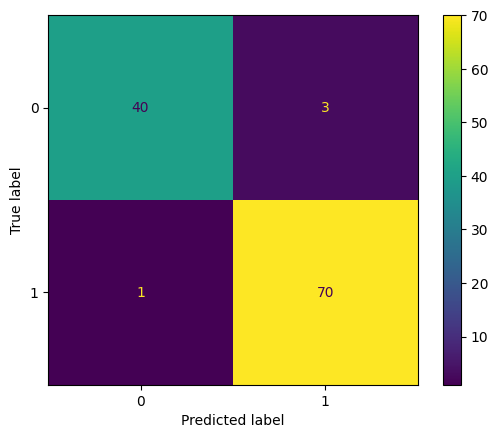

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

data = load_breast_cancer(as_frame=True)

df = data.frame

df.head()

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

> **Remark: Better prediction then Decision Tree**

In [11]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
23,worst area,0.153892
27,worst concave points,0.144663
7,mean concave points,0.106210
20,worst radius,0.077987
6,mean concavity,0.068001
22,worst perimeter,0.067115
2,mean perimeter,0.053270
0,mean radius,0.048703
3,mean area,0.047555
26,worst concavity,0.031802


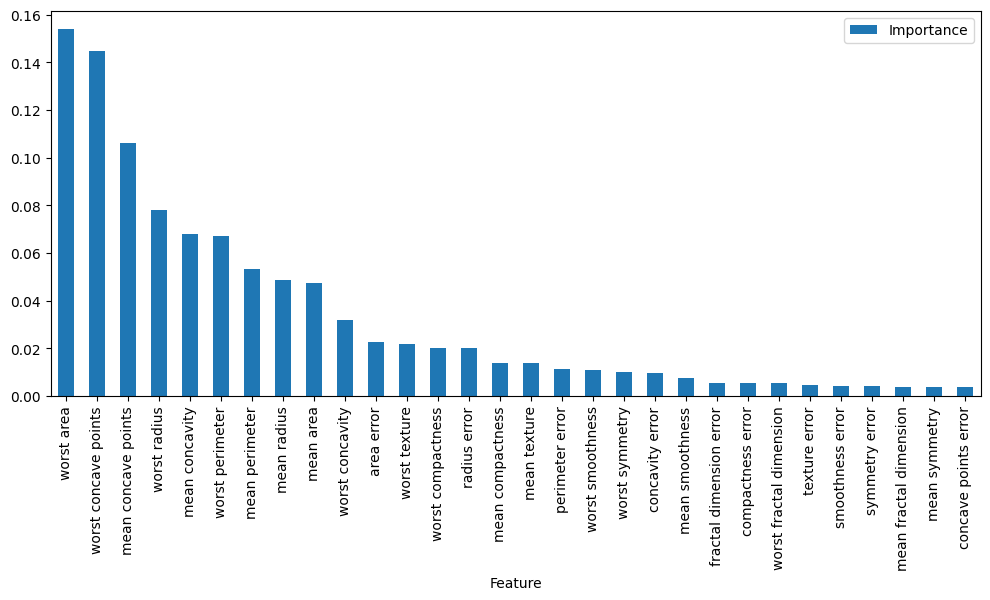

In [12]:
importance.plot.bar(
    x="Feature",
    y="Importance",
    figsize=(12,5)
)

plt.xticks(rotation=90)

plt.show()

**Expiriment**

In [14]:
for depth in [2, 3, 5, 10]:
    
    model = RandomForestClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    print(f"Depth {depth}: {accuracy:.3f}")

Depth 2: 0.965
Depth 3: 0.965
Depth 5: 0.965
Depth 10: 0.965


In [18]:
for feat in [5, 10, 12, 15]:
    
    model = RandomForestClassifier(
        max_features=feat,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    print(f"Depth {depth}: {accuracy:.3f}")

Depth 10: 0.965
Depth 10: 0.956
Depth 10: 0.965
Depth 10: 0.956


In [21]:
for estimation in [10, 20, 40, 70]:
    
    model = RandomForestClassifier(
        n_estimators=estimation,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    print(f"Depth {depth}: {accuracy:.3f}")

Depth 10: 0.956
Depth 10: 0.965
Depth 10: 0.965
Depth 10: 0.965
